In [1]:
from pathlib import Path

from amoc_analysis import data, plotting
import amocatlas

In [6]:
rapid = amocatlas.read.rapid(transport_only=True)

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series



(<Figure size 1000x300 with 1 Axes>,
 <Axes: title={'center': 'AMOC at 26°N'}, xlabel='Time', ylabel='MOC$_{z}$ (Sv)'>)

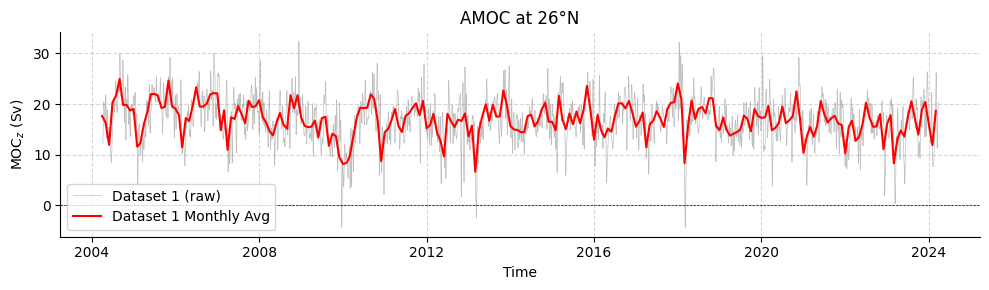

In [7]:
amocatlas.plotters.plot_amoc_timeseries(rapid, varnames=["MOC"], title="AMOC at 26°N")

In [8]:
rapid

<xarray.Dataset> Size: 1MB
Dimensions:           (TIME: 14599)
Coordinates:
  * TIME              (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Data variables:
    TRANS_0_800       (TIME) float64 117kB ...
    TRANS_800_1100    (TIME) float64 117kB ...
    TRANS_1100_3000   (TIME) float64 117kB ...
    TRANS_3000_5000   (TIME) float64 117kB ...
    TRANS_below_5000  (TIME) float64 117kB ...
    TRANS_FC          (TIME) float64 117kB ...
    TRANS_EKMAN       (TIME) float64 117kB ...
    TRANS_UMO         (TIME) float64 117kB ...
    MOC               (TIME) float64 117kB nan nan nan nan ... nan nan nan nan
Attributes: (12/39)
    title:                                 RAPID MOC timeseries
    summary:                               RAPID 26N transport estimates dataset
    description:                           RAPID 26N transport estimates dataset
    program:                               RAPID
    project:                               RAPID-AMOC 26°N array
    license:                               UK Open Government Licence v3.0 ht...
    ...                                    ...
    processing_datasource:                 rapid26n
    variable_mapping:                      {'time': 'TIME', 't_therm10': 'TRA...
    original_variable_metadata:            {'t_therm10': {'long_name': 'Trans...
    applied_variable_mapping:              {'time': 'TIME', 't_therm10': 'TRA...
    version:                               v2024.1a
    files:                                 {'moc_transports.nc': {'featureTyp...

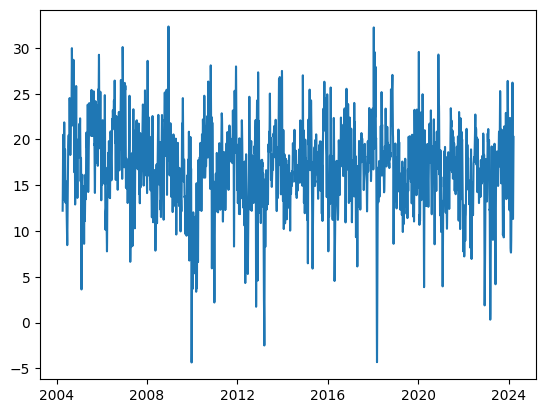

In [12]:
import matplotlib.pyplot as plt

plt.plot(rapid.TIME, rapid["MOC"])

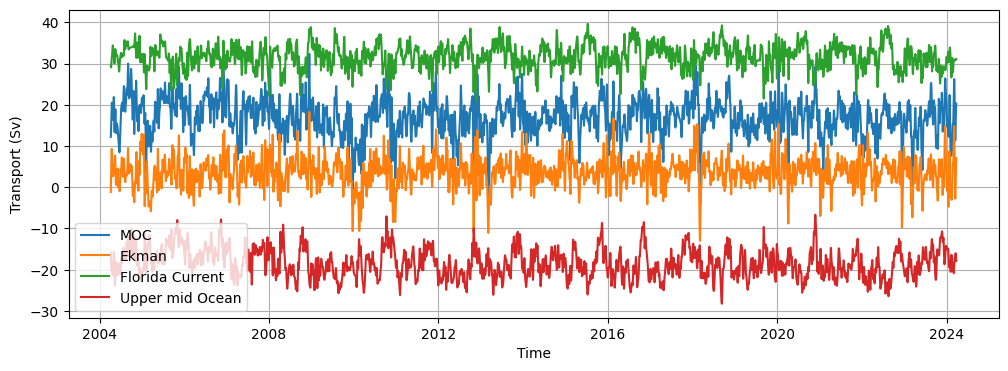

In [30]:
plt.figure(figsize=(12, 4))
plt.plot(rapid.TIME, rapid["MOC"], label="MOC")
plt.plot(rapid.TIME, rapid["TRANS_EKMAN"], label="Ekman")
plt.plot(rapid.TIME, rapid["TRANS_FC"], label="Florida Current")
plt.plot(rapid.TIME, rapid["TRANS_UMO"], label="Upper mid Ocean")
plt.xlabel("Time")
plt.ylabel("Transport (Sv)")
plt.grid()
plt.legend()

### MOC

In [31]:
moc = rapid["MOC"]

In [32]:
# standard deviation
moc_std = moc.std()
print(f"Standard deviation of MOC: {moc_std:.2f} Sv")
# mean
moc_mean = moc.mean()
print(f"Mean of MOC: {moc_mean:.2f} Sv")
# amplitude (max - min)
moc_amplitude = moc.max() - moc.min()
print(f"Amplitude of MOC: {moc_amplitude:.2f} Sv")

Standard deviation of MOC: 4.40 Sv
Mean of MOC: 16.98 Sv
Amplitude of MOC: 36.69 Sv


### EKMAN

In [33]:
ekman = rapid["TRANS_EKMAN"]

In [34]:
# standard deviation
ekman_std = ekman.std()
print(f"Standard deviation of Ekman: {ekman_std:.2f} Sv")
# mean
ekman_mean = ekman.mean()
print(f"Mean of Ekman: {ekman_mean:.2f} Sv")
# amplitude (max - min)
ekman_amplitude = ekman.max() - ekman.min()
print(f"Amplitude of Ekman: {ekman_amplitude:.2f} Sv")

Standard deviation of Ekman: 3.48 Sv
Mean of Ekman: 3.72 Sv
Amplitude of Ekman: 31.29 Sv


### Florida Current

In [35]:
fc = rapid["TRANS_FC"]

In [36]:
# standard deviation
fc_std = fc.std()
print(f"Standard deviation of FC: {fc_std:.2f} Sv")
# mean
fc_mean = fc.mean()
print(f"Mean of FC: {fc_mean:.2f} Sv")
# amplitude (max - min)
fc_amplitude = fc.max() - fc.min()
print(f"Amplitude of FC: {fc_amplitude:.2f} Sv")

Standard deviation of FC: 2.86 Sv
Mean of FC: 31.70 Sv
Amplitude of FC: 18.65 Sv


### Upper mid Ocean

In [37]:
umo = rapid["TRANS_UMO"]

In [38]:
# standard deviation
umo_std = umo.std()
print(f"Standard deviation of UMO: {umo_std:.2f} Sv")
# mean
umo_mean = umo.mean()
print(f"Mean of UMO: {umo_mean:.2f} Sv")
# amplitude (max - min)
umo_amplitude = umo.max() - umo.min()
print(f"Amplitude of UMO: {umo_amplitude:.2f} Sv")

Standard deviation of UMO: 3.42 Sv
Mean of UMO: -18.37 Sv
Amplitude of UMO: 21.59 Sv


### Resampling

#### Subsampling

In [41]:
# every other point: 12-hourly --> 24-hourly
ds_sub_24 = rapid.isel(TIME=slice(None, None, 2))

# or: keep only points at 00:00 each day
ds_sub_24_midnight = rapid.sel(TIME=rapid.TIME.dt.hour == 0)

In [58]:
rapid.TIME

<xarray.DataArray 'TIME' (TIME: 14599)> Size: 117kB
array(['2004-04-02T00:00:00.000000000', '2004-04-02T12:00:00.000000000',
       '2004-04-03T00:00:00.000000000', ..., '2024-03-26T00:00:00.000000000',
       '2024-03-26T12:00:00.000000000', '2024-03-27T00:00:00.000000000'],
      shape=(14599,), dtype='datetime64[ns]')
Coordinates:
  * TIME     (TIME) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Attributes:
    long_name:      Time
    standard_name:  time
    calendar:       gregorian
    units:          datetime64[ns]
    vocabulary:     http://vocab.nerc.ac.uk/collection/P01/current/ELTMEP01/

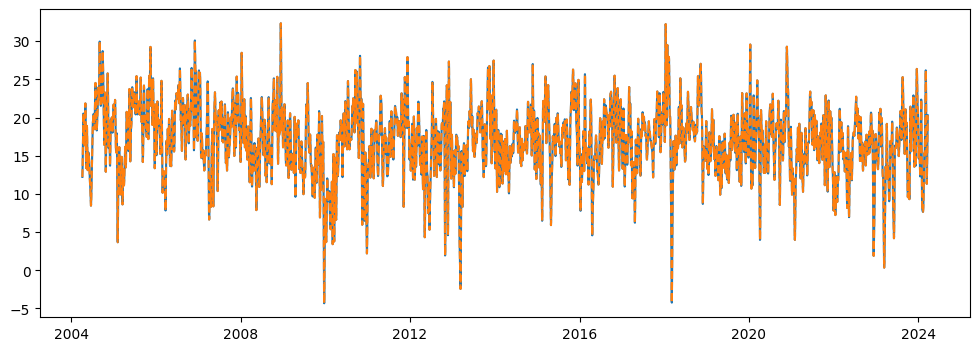

In [61]:
plt.figure(figsize=(12, 4))
plt.plot(ds_sub_24.TIME, ds_sub_24["MOC"], label="MOC (24h subsampled)")
plt.plot(
    ds_sub_24_midnight.TIME,
    ds_sub_24_midnight["MOC"],
    label="MOC (midnight only)",
    linestyle="--",
)

#### bin average with resample

In [ ]:
# daily means, timestamp = start of each day
ds_avg = rapid.resample(TIME="1D").mean()

In [54]:
# weekly means
ds_avg_weekly = rapid.resample(TIME="7D").mean()

In [55]:
# by default: output timestamp is left edge of each bin
# .mean() uses by default skipna = True, so missing values are quitely dropped
# if you want a bin to be NaN whenever ANY point is missing, use skipna = False
# or check counts with .resample(TIME='1D').count()

In [62]:
# visualization

### linearly interpolate

In [65]:
from scipy.interpolate import interp1d
import numpy as np

f = interp1d(
    rapid.TIME, rapid["MOC"], kind="linear", bounds_error=False, fill_value=np.nan
)

In [ ]:
# subsample at exact indices
rapid.isel(TIME=slice(0, 100))

# bin average onto a coraser grid
rapid.resample(TIME="1H").mean()